<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesor Auxilar/Autor: Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - **Main Notes 2026/01** (Francisco Förster Burón):  
>   - https://github.com/fforster/AS4501/tree/main
> - Valetino Gonzales:
>   - https://github.com/cefuente/astroinformatica
> - Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> Paula Caceres, Javiera Toro, Melissa FuenteAlba, ..

In [28]:
import numpy as np
import matplotlib.pyplot as plt

import astroML.datasets

rc_params = {
   'mathtext.fontset': 'cm',     # Set default mathtext font
   'font.family': 'STIXGeneral', # Set default font family
   'xtick.direction': 'in',      # Set default xtickdirecion
   'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
   'ytick.direction': 'in',      # Set default ytickdirecion
   'ytick.minor.visible': True,  # visibility of minor ticks on y-axis
   'grid.linestyle': ':',        # Set grid linestyle
   'grid.alpha': 0.6,            # Set grid transparency
   
}
plt.rcParams.update(rc_params)

Una regresion linea es una funcón escrita como

$$y \equiv f(x, \theta) = \theta_0 + \theta_1 x$$




We use the `astroML.datasets.generate_mu_z` module to create a dataset of redshift vs distance modulus
We are asumming that 

$$\mu = \theta_1 z + \theta_0$$

where $\mu$ is the distance modulus, $z$ is the redshift, and $\theta$ s are the slope and intercept respectively.
In vectorial form we have
$$\mu = \mathbf{\theta} \mathbf{z} = \begin{pmatrix} \theta_1, \theta_0  \end{pmatrix} \cdot \begin{pmatrix} z \\ 1  \end{pmatrix}$$

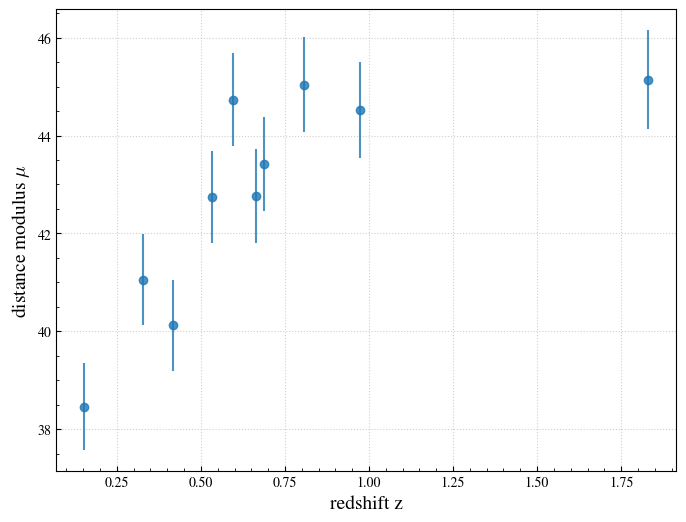

In [34]:
z_sample, mu_sample, dmu_sample  = astroML.datasets.generate_mu_z(10)#, random_state=0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(z_sample, mu_sample, yerr=dmu_sample, fmt='o', alpha=0.8)
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance modulus $\mu$', fontsize=14)
plt.grid()
plt.show()

In [42]:
X = z_sample.reshape(-1, 1)
y = mu_sample

print('Redshift z:', z_sample,'\n', 'Shape:', z_sample.shape)
print('Matrix X:', X,'\n', 'Shape:', X.shape)
print('Distance modulus mu:', y,'\n', 'Shape:', y.shape)

Redshift z: [0.41849681 0.6631733  0.68770425 0.97301727 0.32917915 0.53283116
 0.5943826  0.80780283 0.15369062 1.83025669] 
 Shape: (10,)
Matrix X: [[0.41849681]
 [0.6631733 ]
 [0.68770425]
 [0.97301727]
 [0.32917915]
 [0.53283116]
 [0.5943826 ]
 [0.80780283]
 [0.15369062]
 [1.83025669]] 
 Shape: (10, 1)
Distance modulus mu: [40.12054481 42.76846874 43.41385847 44.53178802 41.0558427  42.74464687
 44.7318848  45.03286885 38.45914406 45.14034046] 
 Shape: (10,)


To find the optimal parameters for our linear model, we minimize the **Residual Sum of Squares (RSS)**. The cost function $J(\theta)$ is defined as the squared norm of the residual vector:
$$J(\theta) = \|\mathbf{y} - \mathbf{X}\theta\|^2 = (\mathbf{y} - \mathbf{X}\theta)^T(\mathbf{y} - \mathbf{X}\theta)$$

Using the properties of the transpose, $(A - B)^T = A^T - B^T$, we expand the expression:

$$\begin{aligned}
J(\theta) &= (\mathbf{y}^T - \theta^T\mathbf{X}^T)(\mathbf{y} - \mathbf{X}\theta) \\
J(\theta) &= \mathbf{y}^T\mathbf{y} - \mathbf{y}^T\mathbf{X}\theta - \theta^T\mathbf{X}^T\mathbf{y} + \theta^T\mathbf{X}^T\mathbf{X}\theta \\
J(\theta) &= \mathbf{y}^T\mathbf{y} - 2\theta^T\mathbf{X}^T\mathbf{y} + \theta^T\mathbf{X}^T\mathbf{X}\theta
\end{aligned}$$

Since $\mathbf{y}^T\mathbf{X}\theta$ is a scalar, it is equal to its own transpose $(\theta^T\mathbf{X}^T\mathbf{y})$. To find the minimum, we differentiate $J(\theta)$ with respect to the parameter vector $\theta$ and set the gradient to zero:
$$\frac{\partial J(\theta)}{\partial \theta} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\theta$$

Solving for $\theta$ to find the optimal value $\hat{\theta}$:
$$\begin{aligned}
-2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\hat{\theta} &= 0 \\
\mathbf{X}^T\mathbf{X}\hat{\theta} &= \mathbf{X}^T\mathbf{y} \\
\hat{\theta} &= \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T\mathbf{y}
\end{aligned}$$

In linear regression, we seek the weights (intercept $\theta_0$ and slope $\theta_1$) that minimize the sum of squared residuals. The analytical solution is the Normal Equation:
$$\hat{\theta} = \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T \mathbf{y}$$

**General Case:** The Covariance MatrixThe OLS derivation assumes that all errors are equal and independent of each other (homoscedasticity). However, in real astronomical data, this is rarely true. Each observation typically has a different uncertainty, requiring us to work with the Covariance Matrix $\mathbf{C}$:

$$\mathbf{C} = \begin{bmatrix} 
\sigma_1^2 & \sigma_{12} & \dots & \sigma_{1n} \\
\sigma_{21} & \sigma_2^2 & \dots & \sigma_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
\sigma_{n1} & \sigma_{n2} & \dots & \sigma_n^2 
\end{bmatrix}$$

In this case, the cost function $J(\theta)$ (often referred to as $\chi^2$ in astronomy) is weighted by the inverse of the covariance matrix:

$$J(\theta) = (\mathbf{y} - \mathbf{X}\theta)^T \mathbf{C}^{-1} (\mathbf{y} - \mathbf{X}\theta)$$

The general solution for the optimal parameters, known as Weighted Least Squares, is:
$$\hat{\theta} = \left(\mathbf{X}^T\mathbf{C}^{-1}\mathbf{X}\right)^{-1}\mathbf{X}^T \mathbf{C}^{-1} \mathbf{y}$$

In [69]:
# Create the design matrix by adding a column of ones for the intercept term
X_mat = np.column_stack((np.ones(X.shape[0]), X))
print('Matrix X_mat:', X_mat,'\n', 'Shape:', X_mat.shape, end='\n\n')

# Apply the normal equation to compute the coefficients
# theta = (X^T @ X)^(-1) @ X^T @ y
theta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y
print('Intercept (theta[0]):', theta[0])
print('Slope (theta[1]):', theta[1])

Matrix X_mat: [[1.         0.41849681]
 [1.         0.6631733 ]
 [1.         0.68770425]
 [1.         0.97301727]
 [1.         0.32917915]
 [1.         0.53283116]
 [1.         0.5943826 ]
 [1.         0.80780283]
 [1.         0.15369062]
 [1.         1.83025669]] 
 Shape: (10, 2)

Intercept (theta[0]): 40.27605446429089
Slope (theta[1]): 3.610431005364429


In [67]:
z_fit  = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100)
X_fit  = np.column_stack((np.ones(z_fit.shape[0]), z_fit.reshape(-1, 1)))
mu_fit = X_fit @ theta 

To measure the accuracy of our model, we calculate the **Mean Squared Error** (MSE). This metric tells us, on average, how far our predictions are from the true astronomical observations
$$\text{MSE}=\frac{1}{n}\sum_{i=1}^{n} \left(y_i - \hat y_i\right)^2$$

where $n$ is the total number of data point, $y_i$ is the real (observed) value, and $\hat y_i$ is the predicted value by the model

In [68]:
mse = np.mean((X_mat @ theta - y) ** 2)
print('Mean Squared Error:', mse)

Mean Squared Error: 2.161926766478539


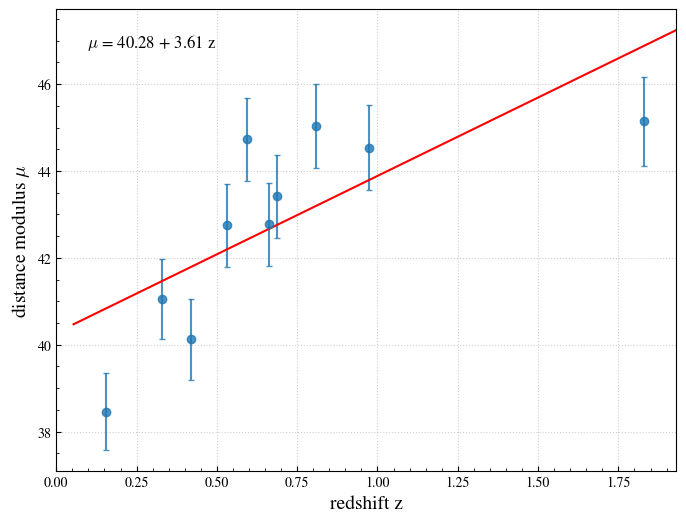

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(z_sample, mu_sample, yerr=dmu_sample, fmt='o', capsize=2, alpha=0.8, label='Data')
ax.plot(z_fit, mu_fit, color='red', label='Linear Fit')
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance modulus $\mu$', fontsize=14)
ax.text(0.05, 0.95, fr'$\mu$ = {theta[0]:.2f} + {theta[1]:.2f} z', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(0.0, z_sample.max()+0.1)
#ax.legend()
plt.grid()
plt.show()

Libraries such as `scikit-learn` and `SciPy` already have these methods implemented. In this lecture, we will prioritize `scikit-learn` because it is the standard for Machine Learning and will be used frequently throughout the rest of this course. However, we also encourage you to explore the `SciPy` documentation.

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X, y)

intercept_sklearn = model.intercept_
slope_sklearn     = model.coef_[0]

print('Intercept (sklearn):', intercept_sklearn)
print('Slope (sklearn):', slope_sklearn)

y_fit_sklearn = model.predict(X)
mse_sklearn = mean_squared_error(y, y_fit_sklearn)
print('MSE (sklearn):', mse_sklearn)

Intercept (sklearn): 40.27605446429088
Slope (sklearn): 3.6104310053644326
MSE (sklearn): 2.1619267664785347


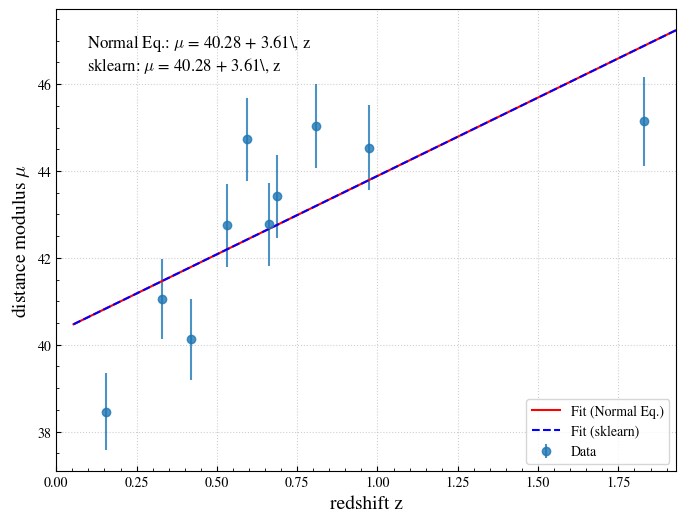

In [ ]:
theta_sklearn  = np.array([intercept_sklearn, slope_sklearn])
mu_fit_sklearn = X_fit @ theta 


fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(z_sample, mu_sample, yerr=dmu_sample, fmt='o', alpha=0.8, label='Data')
ax.plot(z_fit, mu_fit, color='red', label='Fit (Normal Eq.)')
ax.plot(z_fit, mu_fit_sklearn, color='blue', linestyle='--', label='Fit (sklearn)')
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance modulus $\mu$', fontsize=14)
ax.text(0.05, 0.95, fr'Normal Eq.: $\mu$ = {theta[0]:.2f} + {theta[1]:.2f} z', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.90, fr'sklearn: $\mu$ = {intercept_sklearn:.2f} + {slope_sklearn:.2f} z', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(0.0, z_sample.max()+0.1)
ax.legend()
plt.grid()
plt.show()

Ordinary Mean Saquere

Preguntas para ustedes,

¿Qué pasa si usamos todo el set de datos para entrenar y nada para testear?

¿Por qué OLS tiene problemas con datos complejos?

Regularización: Ridge y Lasso
OLS como habiamos conversado puede hacer overfitting cuando hay mucho ruido, ¿qué hacemos en ese caso?

Aqui entra la regularizacion, que busca bajar la varianza de los datos a costa de aumentar el bias.

Tenemos al menos dos opciones, las regresiones de Ridge y Lasso, estos agregan una penalizacion a los datos, para evitar el overfitting.

¿Cómo se diferencian?

Ridge Regression: Penaliza grandes coeficientes pero mantiene todas las caracteristicas de la muestra.

Lasso Regression: Deja unos coeficientes en 0 para asi favorecer el modelo.

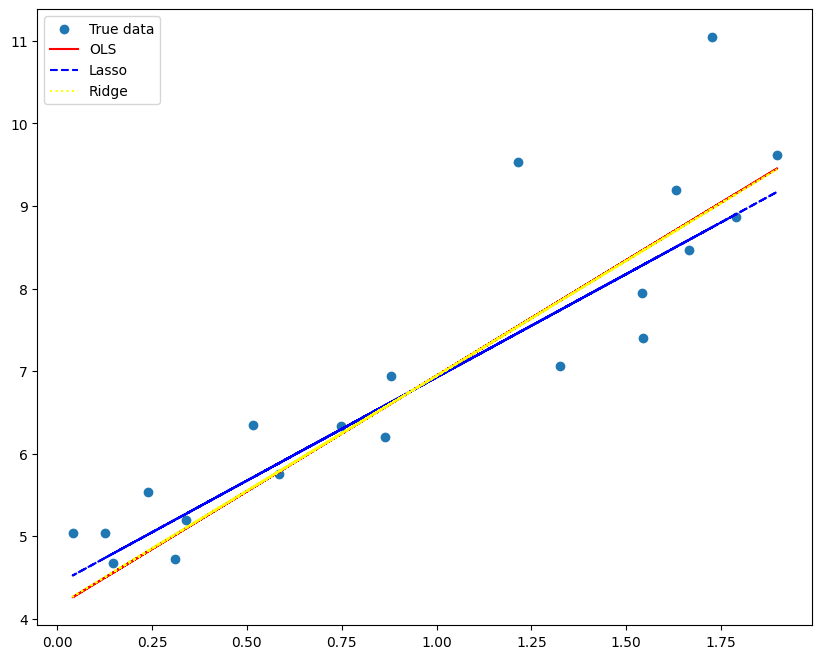

In [6]:
from sklearn.linear_model import Ridge, Lasso

# Fit Lasso and Ridge
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=0.1)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Predecimos
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# Comparamos modelos
fig = plt.figure(figsize=(10,8))
plt.scatter(X_test, y_test, label="True data")
plt.plot(X_test, y_pred, color="red", label="OLS")
plt.plot(X_test, y_pred_lasso, color="blue", linestyle="dashed", label="Lasso")
plt.plot(X_test, y_pred_ridge, color="yellow", linestyle="dotted", label="Ridge")
plt.legend()
plt.show()

¿Cuándo deberíamos usar Lasso en lugar de Ridge?

Lasso es útil cuando esperamos que solo unas pocas características sean realmente importantes, ya que puede eliminar algunas estableciendo sus coeficientes en cero (soluciones dispersas).

Ridge es mejor cuando todas las características son relevantes, pero necesitamos reducir su impacto para evitar el sobreajuste (overfitting).

Ejemplo en Astronomía: Si tenemos un conjunto de datos de espectros de galaxias con muchas longitudes de onda, Lasso puede seleccionar las bandas más importantes. Ridge, en cambio, asegurará que todas las bandas contribuyan, pero con menor influencia.

Manejo de outliers: Regresión de Huber
Si tenemos outliers, OLS no hace el fit correctamente, pues los errores son muy grandes.

Así, la regresión de Huber combina OLS con una perdida absoluta, de esta forma puede manejar los outlier y ser más robusta.

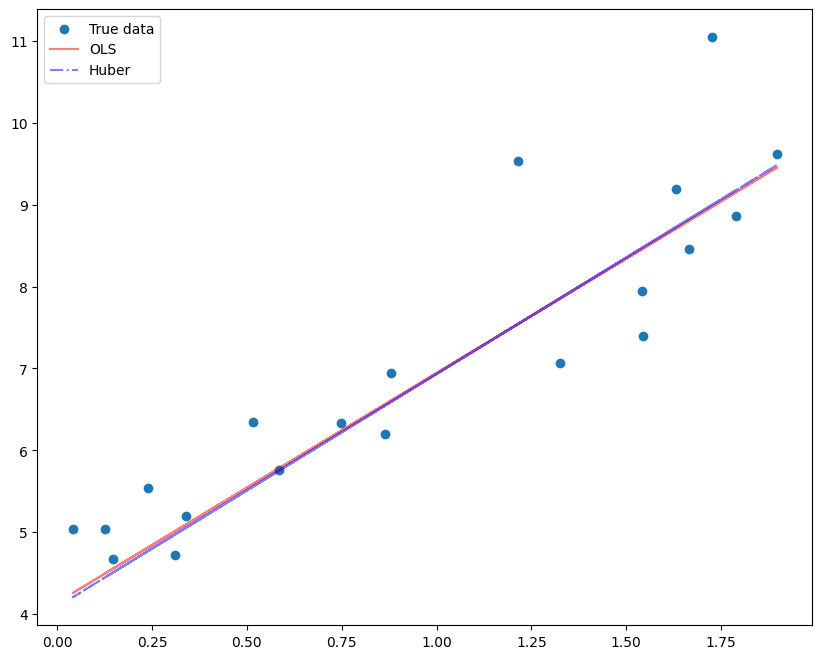

In [7]:
from sklearn.linear_model import HuberRegressor

# Agregamos outliers a la muestra
y_outliers = y.copy()
y_outliers[95:] += 10  # Agregamos errores grandes

# Fit Huber Regression
huber = HuberRegressor()
huber.fit(X_train, y_train.ravel())

# Predecimos
y_pred_huber = huber.predict(X_test)

# Comparamos modelos
fig = plt.figure(figsize=(10,8))
plt.scatter(X_test, y_test, label="True data")
plt.plot(X_test, y_pred, color="red", label="OLS", alpha=0.5)
plt.plot(X_test, y_pred_huber, color="blue", linestyle="dashdot",
         label="Huber",alpha=0.5)
plt.legend()
plt.show()

¿Cómo elegir entre OLS, Ridge, Lasso y Huber para datos astronómicos reales?

OLS: Bueno para conjuntos de datos simples y limpios, sin mucho ruido o valores atípicos.

Ridge: Útil cuando tenemos muchas características correlacionadas (por ejemplo, múltiples colores de galaxias).

Lasso: Ideal cuando queremos una selección automática de características (por ejemplo, identificar las líneas espectrales más relevantes).

Huber: Perfecto para datos con errores de medición o valores extremos (por ejemplo, estrellas variables).